In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score
from lightgbm import LGBMClassifier
from scipy.stats import percentileofscore

In [2]:
df = pd.read_excel("Label+CDK+CDK extended+substructure.xlsx")
X = df.drop(columns=["Label"]).values
y = df["Label"].values

seed = 42
np.random.seed(seed)

In [3]:
clf = LGBMClassifier(
    boosting_type='gbdt',
    colsample_bytree=0.8,
    feature_fraction=0.8,
    bagging_fraction=0.1,
    num_leaves=10,
    min_child_samples=60,
    max_depth=-1,
    learning_rate=0.01,
    n_estimators=300,
    n_jobs=1,
    random_state=42
)

# ---------------------- 3. 10-fold ROC/PR + 整体AUC ----------------------
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_true_all, y_pred_all = [], []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    clf.fit(X_train, y_train)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred_proba)

# 整体 ROC/PR
fpr, tpr, _ = roc_curve(y_true_all, y_pred_all)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_true_all, y_pred_all)
pr_auc = average_precision_score(y_true_all, y_pred_all)

# 保存 10fold 数据
roc_df = pd.DataFrame({"FPR": fpr, "TPR": tpr})
pr_df = pd.DataFrame({"Recall": recall, "Precision": precision})

roc_df.to_excel("10fold_ROC.xlsx", index=False)
pr_df.to_excel("10fold_PR.xlsx", index=False)

print("="*50)
print(f"10-fold CV ROC-AUC: {roc_auc:.4f}")
print(f"10-fold CV PR-AUC:  {pr_auc:.4f}")
print("="*50)

[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fractio

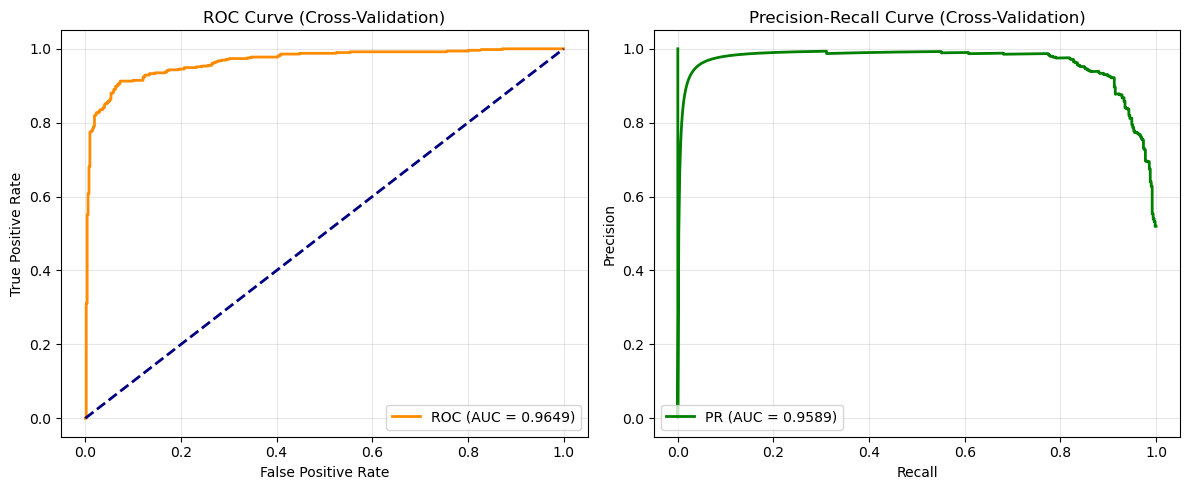

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC 曲线
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (Cross-Validation)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# PR 曲线
ax2.plot(recall, precision, color='green', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (Cross-Validation)')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ROC_PR_CV.png", dpi=600, bbox_inches='tight')
plt.show()

In [5]:
n_permutations = 100 
roc_auc_random = []
pr_auc_random = []

for i in range(n_permutations):

    y_shuffled = np.random.permutation(y)
    y_pred_rand = cross_val_predict(
        clf, X, y_shuffled, cv=10, method="predict_proba", n_jobs=-1
    )[:, 1]
    roc_auc_rand = roc_auc_score(y_shuffled, y_pred_rand)
    pr_auc_rand = average_precision_score(y_shuffled, y_pred_rand)
    roc_auc_random.append(roc_auc_rand)
    pr_auc_random.append(pr_auc_rand)
    if (i + 1) % 10 == 0:
        print(f"Permutation {i+1}/{n_permutations} done")


Permutation 10/100 done
Permutation 20/100 done
Permutation 30/100 done
Permutation 40/100 done
Permutation 50/100 done
Permutation 60/100 done
Permutation 70/100 done
Permutation 80/100 done
Permutation 90/100 done
Permutation 100/100 done


In [6]:
roc_auc_rand_mean = np.mean(roc_auc_random)
roc_auc_rand_std = np.std(roc_auc_random)
pr_auc_rand_mean = np.mean(pr_auc_random)
pr_auc_rand_std = np.std(pr_auc_random)

# P值
p_roc = 1 - percentileofscore(roc_auc_random, roc_auc) / 100
p_pr = 1 - percentileofscore(pr_auc_random, pr_auc) / 100

# 保存随机化数据
rand_df = pd.DataFrame({
    "ROC_random": roc_auc_random,
    "PR_random": pr_auc_random,
    "ROC_original": roc_auc,
    "PR_original": pr_auc
})
rand_df.to_excel("Y_randomization_100.xlsx", index=False)

# 输出结果
print("\n" + "=" * 50)
print("Y-randomization Results")
print(f"ROC-AUC (random): {roc_auc_rand_mean:.4f} ± {roc_auc_rand_std:.4f}")
print(f"PR-AUC  (random): {pr_auc_rand_mean:.4f} ± {pr_auc_rand_std:.4f}")
print(f"P-value (ROC): {p_roc:.4f}")
print(f"P-value (PR): {p_pr:.4f}")
print("=" * 50)


Y-randomization Results
ROC-AUC (random): 0.4657 ± 0.0310
PR-AUC  (random): 0.4601 ± 0.0239
P-value (ROC): 0.0000
P-value (PR): 0.0000


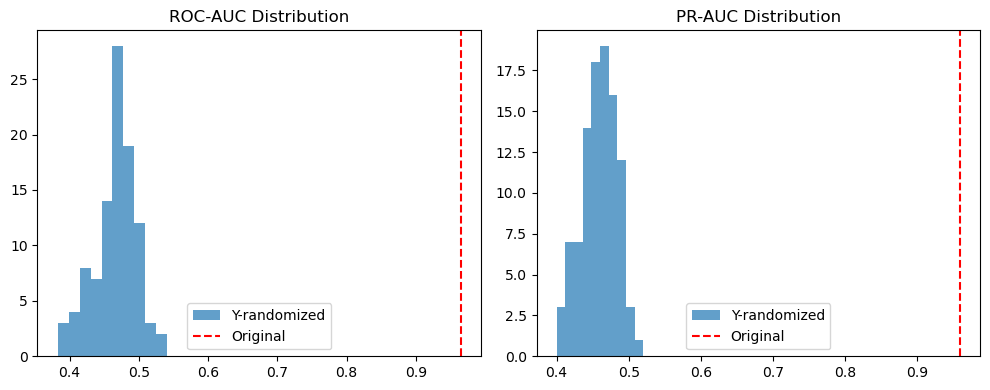

[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fractio

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(roc_auc_random, bins=10, alpha=0.7, label="Y-randomized")
plt.axvline(roc_auc, color="red", linestyle="--", label="Original")
plt.title("ROC-AUC Distribution")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(pr_auc_random, bins=10, alpha=0.7, label="Y-randomized")
plt.axvline(pr_auc, color="red", linestyle="--", label="Original")
plt.title("PR-AUC Distribution")
plt.legend()

plt.tight_layout()
plt.savefig("Y_randomization_result.png", dpi=600)
plt.show()